# Task 1: GPT-style Character-Level LLM on TinyStories

This notebook trains a small GPT model from scratch. The config name is read from the `CONFIG` environment variable (`local` or `gpu`).

## 1. Setup

In [1]:
import os
import random
import sys
import time
from contextlib import nullcontext

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml

sys.path.append("src")
sys.path.append("..")
import eval_task1
from data import ROOT, decode, get_data, load_config
from model import build_model, count_parameters
from utils import (Logger, get_device, load_checkpoint, make_scheduler,
                   peak_memory_mb, save_checkpoint, sync)

config_name = os.environ.get("CONFIG", "local")
cfg = load_config(config_name)

random.seed(cfg["seed"])
np.random.seed(cfg["seed"])
torch.manual_seed(cfg["seed"])
torch.cuda.manual_seed_all(cfg["seed"])

device, device_name = get_device()

out_dir = ROOT / cfg["output_dir"]
logger = Logger(out_dir / "train_log.txt")
logger.log(f"config name: {config_name}")
logger.log(f"device: {device_name}")
logger.log(f"torch version: {torch.__version__}")
logger.log("config:\n" + yaml.dump(cfg, sort_keys=False))

C:\Users\manav\Documents\Lab - 1\data266-lab1-pair17\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


config name: gpu
device: NVIDIA GeForce RTX 4090
torch version: 2.14.1+cu132
config:
seed: 42
output_dir: outputs/gpu
data:
  dataset: roneneldan/TinyStories
  train_stories: 100000
  val_stories: 10000
  separator: <|endoftext|>
  processed_dir: data_processed/gpu
model:
  n_layer: 6
  n_head: 6
  n_embd: 384
  block_size: 256
  dropout: 0.1
train:
  batch_size: 64
  epochs: 10
  lr: 0.0006
  weight_decay: 0.1
  warmup_steps: 1000
  grad_clip: 1.0
  log_every: 100
  spike_factor: 3.0
generate:
  max_new_tokens: 500
  temperatures:
  - 0.8
  - 1.0
  prompts:
  - Once upon a time
  - One day, a little girl
  - The dog was
  - Tom and his mom
  - It was a sunny day



## 2. Load Data

In [2]:
train_loader, val_loader, char_to_idx, idx_to_char = get_data(cfg)
vocab_size = len(char_to_idx)
logger.log(f"vocab size: {vocab_size}")
logger.log(f"train sequences: {len(train_loader.dataset)}, val sequences: {len(val_loader.dataset)}")

vocab size: 115
train sequences: 354329, val sequences: 35407


## 3. Build Model

In [3]:
model = build_model(cfg, vocab_size).to(device)
logger.log(f"parameters: {count_parameters(model)}")

parameters: 10827379

## 4. Train

### Training setup

In [4]:
tcfg = cfg["train"]
optimizer = torch.optim.AdamW(model.parameters(), lr=tcfg["lr"], weight_decay=tcfg["weight_decay"])
total_steps = tcfg["epochs"] * len(train_loader)
scheduler = make_scheduler(optimizer, tcfg["warmup_steps"], total_steps)
use_bf16 = device.type == "cuda" and torch.cuda.is_bf16_supported()

ckpt_dir = out_dir / "checkpoints"
last_path = ckpt_dir / "last.pt"
best_path = ckpt_dir / "best.pt"
history_path = out_dir / "history.csv"

start_epoch, step, best_val = 0, 0, float("inf")
history = []
if last_path.exists():
    start_epoch, step, best_val = load_checkpoint(last_path, model, optimizer, scheduler, device)
    history = pd.read_csv(history_path).iloc[:start_epoch].to_dict("records")
    logger.log(f"resumed from last.pt at epoch {start_epoch}, step {step}")
logger.log(f"bf16 autocast: {use_bf16}")


def autocast():
    if use_bf16:
        return torch.autocast("cuda", dtype=torch.bfloat16)
    return nullcontext()


@torch.no_grad()
def evaluate():
    model.eval()
    total, count = 0.0, 0
    for x, y in val_loader:
        x, y = x.to(device), y.to(device)
        with autocast():
            _, loss = model(x, y)
        total += loss.item() * x.size(0)
        count += x.size(0)
    model.train()
    return total / count

bf16 autocast: True


### Training loop

In [5]:
grad_avg = None

for epoch in range(start_epoch, tcfg["epochs"]):
    torch.manual_seed(cfg["seed"] + epoch)
    model.train()
    epoch_start = time.time()
    interval_start = time.time()
    interval_loss, interval_n, interval_tokens = 0.0, 0, 0
    epoch_loss, epoch_n = 0.0, 0
    nan_count, spike_count = 0, 0
    grad_sum, grad_max, epoch_tokens = 0.0, 0.0, 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        with autocast():
            _, loss = model(x, y)
        if not torch.isfinite(loss):
            nan_count += 1
            continue
        loss.backward()
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), tcfg["grad_clip"]).item()
        if grad_avg is not None and grad_norm > tcfg["spike_factor"] * grad_avg:
            spike_count += 1
        grad_avg = grad_norm if grad_avg is None else 0.9 * grad_avg + 0.1 * grad_norm
        grad_sum += grad_norm
        grad_max = max(grad_max, grad_norm)
        epoch_tokens += x.numel()
        optimizer.step()
        scheduler.step()
        step += 1

        interval_loss += loss.item()
        interval_n += 1
        interval_tokens += x.numel()
        epoch_loss += loss.item()
        epoch_n += 1

        if step % tcfg["log_every"] == 0:
            speed = interval_tokens / (time.time() - interval_start)
            logger.log(f"step {step} | train loss {interval_loss / interval_n:.4f} | "
                       f"lr {scheduler.get_last_lr()[0]:.6f} | grad norm {grad_norm:.3f} | "
                       f"tokens/sec {speed:.0f}")
            interval_start = time.time()
            interval_loss, interval_n, interval_tokens = 0.0, 0, 0

    train_loss = epoch_loss / epoch_n
    train_time = time.time() - epoch_start
    val_loss = evaluate()
    epoch_time = time.time() - epoch_start
    mem = peak_memory_mb(device)
    mem_text = f"{mem:.0f} MB" if mem is not None else "n/a"
    logger.log(f"epoch {epoch + 1}/{tcfg['epochs']} | train loss {train_loss:.4f} | "
               f"val loss {val_loss:.4f} | time {epoch_time:.1f}s | nan losses {nan_count} | "
               f"grad spikes {spike_count} | peak memory {mem_text}")

    history.append({"epoch": epoch + 1, "step": step, "train_loss": train_loss,
                    "val_loss": val_loss, "epoch_time": epoch_time,
                    "nan_losses": nan_count, "grad_spikes": spike_count,
                    "grad_norm_mean": grad_sum / epoch_n, "grad_norm_max": grad_max,
                    "tokens_per_sec": epoch_tokens / train_time,
                    "peak_memory_mb": mem if mem is not None else float("nan")})
    pd.DataFrame(history).to_csv(history_path, index=False)

    if val_loss < best_val:
        best_val = val_loss
        save_checkpoint(best_path, model, optimizer, scheduler, epoch + 1, step, best_val, cfg)
    save_checkpoint(last_path, model, optimizer, scheduler, epoch + 1, step, best_val, cfg)

logger.log(f"training finished, best val loss {best_val:.4f}")

step 100 | train loss 3.3490 | lr 0.000061 | grad norm 0.720 | tokens/sec 329174


step 200 | train loss 2.4091 | lr 0.000121 | grad norm 0.597 | tokens/sec 356079


step 300 | train loss 2.2591 | lr 0.000181 | grad norm 0.814 | tokens/sec 361179


step 400 | train loss 2.0531 | lr 0.000241 | grad norm 1.082 | tokens/sec 358633


step 500 | train loss 1.7789 | lr 0.000301 | grad norm 0.832 | tokens/sec 364762


...

step 55100 | train loss 0.5402 | lr 0.000060 | grad norm 0.261 | tokens/sec 346828


step 55200 | train loss 0.5368 | lr 0.000060 | grad norm 0.240 | tokens/sec 358719


step 55300 | train loss 0.5392 | lr 0.000060 | grad norm 0.249 | tokens/sec 323616


epoch 10/10 | train loss 0.5388 | val loss 0.5332 | time 281.6s | nan losses 0 | grad spikes 0 | peak memory 3925 MB


training finished, best val loss 0.5332


## 5. Loss Curves

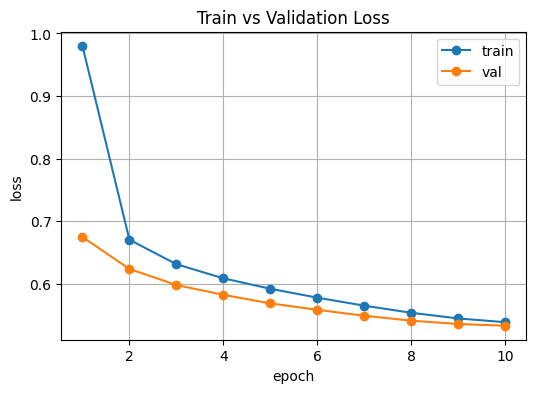

In [6]:
history_df = pd.read_csv(history_path)

plt.figure(figsize=(6, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig(out_dir / "loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Generate Text

In [7]:
model.load_state_dict(torch.load(best_path, map_location=device)["model"])
model.eval()

gcfg = cfg["generate"]
settings = [("greedy", {"greedy": True})]
settings += [(f"temperature {t}", {"temperature": t}) for t in gcfg["temperatures"]]

torch.manual_seed(cfg["seed"])
samples, continuations = [], []
gen_tokens, gen_time = 0, 0.0

for name, kwargs in settings:
    for prompt in gcfg["prompts"]:
        start = torch.tensor([[char_to_idx[c] for c in prompt]], device=device)
        sync(device)
        t0 = time.time()
        out = model.generate(start, gcfg["max_new_tokens"], **kwargs)
        sync(device)
        gen_time += time.time() - t0
        gen_tokens += gcfg["max_new_tokens"]
        ids = out[0].tolist()
        samples.append(f"[{name}] prompt: {prompt}\n{decode(ids, idx_to_char)}\n")
        continuations.append(decode(ids[start.size(1):], idx_to_char))

with open(out_dir / "samples.txt", "w") as f:
    f.write("\n".join(samples))

gen_speed = gen_tokens / gen_time
print(f"generation tokens/sec: {gen_speed:.0f}")
print("\n".join(samples[0::len(gcfg["prompts"])]))

generation tokens/sec: 96
[greedy] prompt: Once upon a time
Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she saw a big tree with a big branch on it. She wanted to climb it, but she was too small to reach the top.

Lily saw a big tree with a lot of branches. She thought it would be fun to climb the tree and see the birds. She thought they were fun and started to climb the tree. She climbed the tree and saw a big tree. She climbed the tree and saw a big tree. She wanted to climb the tree and see the birds.

She 

[temperature 0.8] prompt: Once upon a time
Once upon a time, there was a thick car named Daisy. Daisy was very small and could drive. One day, Daisy was sad because she lost her favorite toy. She looked everywhere but couldn't find it.

Daisy wanted to help her friend, so she ran to the car. She said, "Hi, Daisy! I'm here to find my toy." Daisy was surprised and said, "Wow, that's a great idea! Let's look for it."

The

## 7. Metrics

In [8]:
@torch.no_grad()
def val_accuracy():
    total, count = 0.0, 0
    for x, y in val_loader:
        x, y = x.to(device), y.to(device)
        with autocast():
            logits, _ = model(x, y)
        total += eval_task1.top1_accuracy(logits, y) * y.numel()
        count += y.numel()
    return total / count


h = pd.read_csv(history_path)
final_train = h["train_loss"].iloc[-1]
final_val = h["val_loss"].iloc[-1]
peak_mem = h["peak_memory_mb"].max()

rows = [
    ("final train loss", final_train),
    ("final val loss", final_val),
    ("perplexity (train)", eval_task1.perplexity(final_train)),
    ("perplexity (val)", eval_task1.perplexity(final_val)),
    ("bits per character (train)", eval_task1.bits_per_char(final_train)),
    ("bits per character (val)", eval_task1.bits_per_char(final_val)),
    ("generalization gap", eval_task1.generalization_gap(final_train, final_val)),
    ("top-1 accuracy (val)", val_accuracy()),
    ("distinct-1", eval_task1.distinct_n(continuations, 1)),
    ("distinct-2", eval_task1.distinct_n(continuations, 2)),
    ("distinct-3", eval_task1.distinct_n(continuations, 3)),
    ("repeated 4-gram rate", eval_task1.repeated_ngram_rate(continuations, 4)),
    ("mean grad norm", h["grad_norm_mean"].mean()),
    ("max grad norm", h["grad_norm_max"].max()),
    ("grad spikes", int(h["grad_spikes"].sum())),
    ("nan count", int(h["nan_losses"].sum())),
    ("parameter count", count_parameters(model)),
    ("train tokens/sec", h["tokens_per_sec"].mean()),
    ("generation tokens/sec", gen_speed),
    ("peak memory (MB)", peak_mem if pd.notna(peak_mem) else "n/a"),
    ("total training time (s)", h["epoch_time"].sum()),
    ("device name", device_name),
]

metrics = pd.DataFrame(rows, columns=["metric", "value"])
metrics.to_csv(out_dir / "metrics_report.csv", index=False)
metrics

,metric,value
0,final train loss,0.538813
1,final val loss,0.533198
2,perplexity (train),1.71397
3,perplexity (val),1.704374
4,bits per character (train),0.777342
5,bits per character (val),0.769242
6,generalization gap,-0.005615
7,top-1 accuracy (val),0.828874
8,distinct-1,0.294001
9,distinct-2,0.676431
